# UHPC Dataset


## Data preprocessing

### Import the Data

In [46]:
import pandas as pd
import numpy as np
from pipeline import preprocessing_pipeline
from sklearn.model_selection import train_test_split


In [47]:
df = pd.read_excel('../Datasets/UHPC_data_v2.xlsx', sheet_name=1, header=2)

tw_ei_da_co=len(df[df.columns[53]])
print(f'Number of rows in 28-Day = {tw_ei_da_co}')

Number of rows in 28-Day = 2188


### Initial cleaning

In [48]:
# drop the missing rows where the target value is missing
tw_ei_da = df.columns[53]
df_drop=df.dropna(subset=[tw_ei_da]).copy()
print(f'Number of rows in 28-Day = {len(df_drop[df.columns[53]])}')

Number of rows in 28-Day = 2073


In [49]:
df_drop[df.columns[37]].value_counts().count()

np.int64(127)

In [50]:
type_columns_to_clean = [
    df_drop.columns[2],  # Cement Type
    df_drop.columns[6],  # Fly Ash Type
    df_drop.columns[14], # Slag Type
    df_drop.columns[20], # Sustainable Filler Type
    df_drop.columns[22], # Sand Type
    df_drop.columns[24], # Fiber Type
    df_drop.columns[30], # Synergetic Fiber Type
    df_drop.columns[37], # Superplasticizer Type
    df_drop.columns[39]  # Curing Type
]
#lowering and stripping
for col in type_columns_to_clean:
    df_drop[col] = df_drop[col].astype(str).str.lower().str.strip()

In [51]:
# extracting values from the string cells in curing pressure z.B. 1.2 Mpa for 4 and 5 hrs
pressure_col = df_drop.columns[42] 
df_drop[pressure_col] = df_drop[pressure_col].astype(str).str.extract(r'([0-9.]+)').astype(float)

In [52]:
df_drop.describe()

,Cement Amount (kg/m³),Cement Grade (Mpa),Silica Fume (kg/m³),Flayash Amount (kg/m³),Limestone Powder (kg/m3),Quartzpowder (kg/m3),Glass powder (kg/m3),Rice husk ash (kg/m3),Metakaolin (kg/m³),GGBFS (kg/m³),...,Air Content %,Air Void %,Porosity,Water absorption (%),28-day Shrinkage (µstrain),56-day Shrinkage (µstrain),Cycles,Total Charge Passed (Coulombs),Surface Resistivity (kΩ-mm),Unnamed: 90
count,2073.000000,1274.000000,2073.000000,2073.000000,2073.000000,2073.000000,2073.000000,2073.000000,2073.000000,2073.000000,...,47.000000,38.000000,239.000000,23.000000,102.000000,62.000000,22.000000,108.000000,13.000000,158.000000
mean,786.189440,48.925432,180.798830,59.566706,13.608399,58.900000,32.362169,2.340646,4.901013,42.025904,...,3.332553,4.513158,6.223389,1.325391,446.041115,358.112903,76.818182,410.327778,460.615385,2017.196203
std,202.379283,4.833798,90.039356,143.841370,62.876265,113.372848,123.650305,22.747110,31.729998,141.933403,...,1.073982,1.253788,5.167403,0.618443,399.795696,346.381061,40.056836,559.598811,67.779715,4.124587
min,170.000000,42.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.400000,2.200000,0.690000,0.430000,6.000000,25.000000,17.700000,9.000000,386.000000,2006.000000
25%,664.000000,42.500000,133.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.430000,3.800000,2.150000,0.825000,229.500000,240.000000,28.700000,104.625000,424.000000,2015.000000
50%,788.500000,52.500000,197.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.300000,4.400000,4.400000,1.200000,320.000000,288.000000,105.500000,142.000000,437.000000,2018.000000
75%,900.000000,52.500000,230.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,5.200000,9.450000,1.730000,467.250000,379.250000,106.000000,421.250000,463.000000,2020.000000
max,1856.700000,53.000000,617.647059,1152.000000,1058.200000,528.000000,1067.000000,481.060000,510.000000,768.000000,...,6.300000,7.900000,25.890000,2.637000,2100.000000,2300.000000,109.000000,1970.000000,603.000000,2025.000000


### Defining the dictionaries

In [53]:
ingredients = {
    # w/o types
    "Silica Fume":      {"amount": df_drop.columns[4],  
                         "type": None, "extras": []},
    "Limestone Powder": {"amount": df_drop.columns[7],  
                         "type": None, "extras": []},
    "Quartz Powder":    {"amount": df_drop.columns[8],  
                         "type": None, "extras": []},
    "Glass Powder":     {"amount": df_drop.columns[9],  
                         "type": None, "extras": []},
    "Rice Husk Ash":    {"amount": df_drop.columns[10], 
                         "type": None, "extras": []},
    "Metakaolin":       {"amount": df_drop.columns[11], 
                         "type": None, "extras": []},
    "Nano-CaCO3":       {"amount": df_drop.columns[15], 
                         "type": None, "extras": []},
    "Nano-Al2O3":       {"amount": df_drop.columns[16], 
                         "type": None, "extras": []},
    "Nano-TiO2":        {"amount": df_drop.columns[17], 
                         "type": None, "extras": []},
    "Nano-Silica":      {"amount": df_drop.columns[18], 
                         "type": None, "extras": []},
    "Water":            {"amount": df_drop.columns[36],
                         "type": None, "extras": []},

    # amount and type
    "Fly Ash":          {"amount": df_drop.columns[5],  
                         "type": df_drop.columns[6],  "extras": []},
    "Slag":              {"amount": df_drop.columns[13], 
                         "type": df_drop.columns[14], "extras": []},
    "Superplasticizer": {"amount": df_drop.columns[38], 
                         "type": df_drop.columns[37], "extras": []},
    "Sustainable Filler": {"amount": df_drop.columns[19], 
                           "type": df_drop.columns[20], "extras": []},

    # amount, type and other parameters
    "Sand": {
        "amount": df_drop.columns[21], 
        "type": df_drop.columns[22], 
        "extras": [df_drop.columns[23]]  # max size
    },
    "Fiber": {
        "amount": df_drop.columns[25], 
        "type": df_drop.columns[24], 
        "extras": [df_drop.columns[26], # length
                   df_drop.columns[27], # diameter
                   df_drop.columns[28], # tensile
                   df_drop.columns[29]] # Young's modulus

    },
    "Synergetic Fiber": {
        "amount": df_drop.columns[31], 
        "type": df_drop.columns[30], 
        "extras": [df_drop.columns[32], # length
                   df_drop.columns[33], # diameter
                   df_drop.columns[34], # tensile strength
                   df_drop.columns[35]] # Young's modulus
    }
}

cement_amt_r   = df.columns[1]
cement_type_r = df.columns[2]
cement_grade_r = df.columns[3]

curing_type_r  = df.columns[39]
curing_temp_r  = df.columns[40]
curing_humid_r = df.columns[41]
curing_press_r = pressure_col
sp_type_r = df.columns[37]

### Feature policy 

In [54]:
# 100, 50, 20
feature_policy = 50

# gather all raw features from the dictionary
amount_cols = [data["amount"] for data in ingredients.values() if data["amount"] is not None]
type_cols = [data["type"] for data in ingredients.values() if data["type"] is not None]
extra_cols = []
for data in ingredients.values():
    extra_cols.extend(data["extras"])



# define curing and cement features
other_raw = [
    cement_amt_r,  # Cement Amount
    cement_type_r,  # Cement Type
    cement_grade_r,  # Cement Grade
    curing_type_r, # Curing Type
    curing_temp_r, # Curing Temp
    curing_humid_r, # Curing Humidity
    pressure_col    # Curing Pressure
]

# combine all features  
all_features = amount_cols + type_cols + extra_cols + other_raw
# Ensure no KeyError by checking what is actually in the dataframe
all_features = [f for f in all_features if f in df_drop.columns]

# calculate missing percentages
missing_perc = df_drop[all_features].isnull().sum() / len(df_drop) * 100

# Policy logic
if feature_policy == 100:
    cols_to_drop = []
    
elif feature_policy == 50:
    cols_to_drop = missing_perc[missing_perc > 50].index.tolist()
    
elif feature_policy == 20:
    cols_to_drop = missing_perc[missing_perc > 20].index.tolist()
    
else:
    raise ValueError("Please choose policy from the provided options: 100, 50, 20")

# execute the drop
df_drop = df_drop.drop(columns=cols_to_drop)


print(f"Policy: {feature_policy}")
print(f"{len(all_features)} total raw features.")
print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")

Policy: 50
41 total raw features.
Dropped 13 columns: ['Amount / Quantity of Fiber .1', 'Fly Ash Type ', 'Type of Slag ', 'Type of Filler ', 'Type of Fiber .1', 'Tensile Strength (MPa)', 'Nominal Young’s modulus, Gpa', 'Length (mm).1', 'Diameter (mm).1', 'Tensile Strength (MPa).1', 'Nominal Young’s modulus, Gpa.1', 'Unnamed: 41', 'Unnamed: 42']


### Semantic Recoding

In [ ]:
if feature_policy != 100:
    print("Applying semantic recoding")
    
    cement_type_col = df.columns[2]
    if cement_type_col in df_drop.columns:
        df_drop[cement_type_col] = df_drop[cement_type_col].fillna("unknown_type")

    # Clean ingredients
    for name, data in ingredients.items():
        amount_col = data["amount"]
        type_col = data["type"]
        extras_col = data["extras"]
        
        if amount_col in df_drop.columns:
            
            df_drop[amount_col] = df_drop[amount_col].astype(str).str.extract(r'([0-9.]+)').astype(float)
            
            # amount = 0 or nan
            not_used = (df_drop[amount_col] == 0) | (df_drop[amount_col].isnull())
            
            # if not used types and extra parameters don't apply
            if type_col is not None and type_col in df_drop.columns:
                df_drop.loc[not_used, type_col] = 'not_applicable'
                
            for extra in extras_col:
                if extra in df_drop.columns:
                    # extract the numbers and force the column to be a float
                    df_drop[extra] = df_drop[extra].astype(str).str.extract(r'([0-9.]+)').astype(float)
                    
                    # assign 0.0
                    df_drop.loc[not_used, extra] = 0.0
                
            # amount > 0 but type is missing
            if type_col is not None and type_col in df_drop.columns:
                missing_type = (df_drop[amount_col] > 0) & (df_drop[type_col].isnull())
                df_drop.loc[missing_type, type_col] = "unknown_type"
            

            if type_col is not None and type_col in df_drop.columns:
                # type exists but amount is missing
                missing_amt = (df_drop[type_col].notnull()) & (df_drop[amount_col].isnull())
            else:
                missing_amt = df_drop[amount_col].isnull()

            # keep the original column numeric
            df_drop.loc[missing_amt, amount_col] = 0.0

    # clean the curing regime
    if curing_type_r in df_drop.columns:
    
        # Safely check which numeric columns 
        has_temp = curing_temp_r in df_drop.columns
        has_humid = curing_humid_r in df_drop.columns
        has_press = pressure_col in df_drop.columns
        
        # build the has_numeric_data mask
        has_numeric_data = pd.Series(False, index=df_drop.index)
        if has_temp:
            has_numeric_data = has_numeric_data | (df_drop[curing_temp_r] >= 0)
        if has_humid:
            has_numeric_data = has_numeric_data | (df_drop[curing_humid_r] >= 0)
        if has_press:
            has_numeric_data = has_numeric_data | (df_drop[pressure_col] >= 0)

        # if t, h, p are not nan but type is blank    
        type_is_null = df_drop[curing_type_r].isnull()
        df_drop.loc[type_is_null & has_numeric_data, curing_type_r] = "unknown_type"

        # everything is nan 
        df_drop[curing_type_r] = df_drop[curing_type_r].fillna("not_applicable")

        # conditional average imputation for missing temperatures
        unique_types = df_drop[curing_type_r].dropna().unique()
        for c_type in unique_types:
            is_this_type = df_drop[curing_type_r] == c_type
            
            if has_temp:
                type_temp_mean = df_drop.loc[is_this_type, curing_temp_r].mean()
                df_drop.loc[is_this_type & df_drop[curing_temp_r].isnull(), curing_temp_r] = type_temp_mean
            if has_humid:
                type_humid_mean = df_drop.loc[is_this_type, curing_humid_r].mean()
                df_drop.loc[is_this_type & df_drop[curing_humid_r].isnull(), curing_humid_r] = type_humid_mean
            if has_press:
                type_press_mean = df_drop.loc[is_this_type, pressure_col].mean()
                df_drop.loc[is_this_type & df_drop[pressure_col].isnull(), pressure_col] = type_press_mean

else:
    print("Skipping semantic recoding (Full Raw)")

Applying semantic recoding...


### Feature Selection

In [56]:
# define the base feature groups
mix_features = [data["amount"] for data in ingredients.values() if data["amount"] is not None]

type_cols = [data["type"] for data in ingredients.values() if data["type"] is not None]

extra_features = []
for data in ingredients.values():
    extra_features.extend(data["extras"])

cement_features = [cement_amt_r, cement_type_r, cement_grade_r]

curing_features = [
    curing_type_r, 
    curing_temp_r,
    curing_humid_r,
    pressure_col    
] 

# combine everything and intersect
keep_features_raw = cement_features + mix_features + type_cols + extra_features + curing_features
keep_features = list(df_drop.columns.intersection(keep_features_raw))

### Splitting

In [57]:
Y = df_drop['28-Day']
X = df_drop[keep_features]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

X_test, X_val, Y_test, Y_val = train_test_split(X_test, Y_test, test_size=0.5, random_state=42)

In [58]:
# numerical features
raw_numeric_features = [col for col in (amount_cols + extra_cols) if col in X_train.columns]

# evaluate std 5 
low_raw = X_train[raw_numeric_features].mean() - 5 * X_train[raw_numeric_features].std()
up_raw = X_train[raw_numeric_features].mean() + 5 * X_train[raw_numeric_features].std()

#  row masks using the raw boundaries
train_bounds_mask = ((X_train[raw_numeric_features] >= low_raw) & (X_train[raw_numeric_features] <= up_raw)).all(axis=1)
test_bounds_mask = ((X_test[raw_numeric_features] >= low_raw) & (X_test[raw_numeric_features] <= up_raw)).all(axis=1)
val_bounds_mask = ((X_val[raw_numeric_features] >= low_raw) & (X_val[raw_numeric_features] <= up_raw)).all(axis=1)

X_train_norm = X_train[train_bounds_mask]
Y_train_norm = Y_train[train_bounds_mask]
X_val_norm = X_val[val_bounds_mask]

X_test_norm = X_test[test_bounds_mask]
Y_test_norm = Y_test[test_bounds_mask]
Y_val_norm = X_val[val_bounds_mask]

In [59]:
# define One hot columns
one_hot_encode_cols = [bundle["type"] for bundle in ingredients.values() if bundle["type"] is not None and bundle["type"] in X_train_norm.columns and bundle["type"] != sp_type_r]
if curing_type_r in X_train_norm.columns:
    one_hot_encode_cols.append(curing_type_r)

# define Target encode columns
target_encode_cols = [col for col in [cement_type_r, sp_type_r] if col in X_train_norm.columns]

### Formatting numeric features and handling coerced NaNs

In [60]:
# all new numeric features to be scaled
new_numerics = [cement_amt_r, cement_grade_r, curing_temp_r, curing_humid_r, pressure_col]

all_numeric_features = new_numerics + mix_features + extra_features

#  find which ones survived the policy drop
valid_numeric_features = [col for col in all_numeric_features if col in X_train_norm.columns]


In [61]:
# only pass columns that actually exist in the raw dataframe
fin_one_hot = [col for col in one_hot_encode_cols if col in X_train_norm.columns]
fin_target = [col for col in target_encode_cols if col in X_train_norm.columns]
fin_numeric = [col for col in valid_numeric_features if col in X_train_norm.columns]

# initialize the pipeline
pipe_line = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric)

In [79]:
x = pd.Series(fin_one_hot)
x

0         Sand Type
1    Type of Fiber 
2       Unnamed: 39
dtype: str

## Model training

### Import libraries

In [62]:
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV

In [63]:
experiment_results = []

In [19]:
#Base raw
#XGB
pipe_xgb_raw = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=XGBRegressor(random_state=42))

pipe_xgb_raw.fit(X_train, Y_train) 
Y_pred_xgb_raw = pipe_xgb_raw.predict(X_test)

mae_xgb = mean_absolute_error(Y_test,Y_pred_xgb_raw)
rmse_xgb =root_mean_squared_error(Y_test, Y_pred_xgb_raw)
r2_xgb = r2_score(Y_test, Y_pred_xgb_raw)

experiment_results.append({
    'Experiment': 'BaseRaw',
    'Model': 'XGBRegressor',
    'MAE': mae_xgb,
    'RMSE': rmse_xgb,
    'R2': r2_xgb
})

# Hist
pipe_hist_raw = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=HistGradientBoostingRegressor(random_state=42))

pipe_hist_raw.fit(X_train, Y_train) 
Y_pred_hist_raw = pipe_hist_raw.predict(X_test)

mae_hist = mean_absolute_error(Y_test,Y_pred_hist_raw)
rmse_hist =root_mean_squared_error(Y_test, Y_pred_hist_raw)
r2_hist = r2_score(Y_test, Y_pred_hist_raw)

experiment_results.append({
    'Experiment': 'BaseRaw',
    'Model': 'HistGradientBoostingRegressor',
    'MAE': mae_hist,
    'RMSE': rmse_hist,
    'R2': r2_hist
})

#Ada
pipe_ada_raw = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=AdaBoostRegressor(random_state=42))

pipe_ada_raw.fit(X_train, Y_train) 
Y_pred_ada_raw = pipe_ada_raw.predict(X_test)

mae_ada = mean_absolute_error(Y_test,Y_pred_ada_raw)
rmse_ada =root_mean_squared_error(Y_test, Y_pred_ada_raw)
r2_ada = r2_score(Y_test, Y_pred_ada_raw)
experiment_results.append({
    'Experiment': 'BaseRaw',
    'Model': 'AdaBoostRegressor',
    'MAE': mae_ada,
    'RMSE': rmse_ada,
    'R2': r2_ada
})

# Conducting experiments

#GridSearchCV + no outliers 5std
#XGB
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],      
    'model__learning_rate': [0.05, 0.1, 0.2],   
    'model__max_depth': [3, 5, 7]               
}
pipe_xgb_grid = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=XGBRegressor(random_state=42))
grid_s_xgb = GridSearchCV(
    estimator=pipe_xgb_grid,
    param_grid=param_grid_xgb,
    cv=5,               
    scoring='r2',       
    n_jobs=-1,          
    verbose=1           
)
grid_s_xgb.fit(X_train_norm, Y_train_norm) 
best_model_xgb = grid_s_xgb.best_estimator_
Y_pred_xgb_grid = best_model_xgb.predict(X_test_norm)

mae_xgb = mean_absolute_error(Y_test_norm,Y_pred_xgb_grid)
rmse_xgb =root_mean_squared_error(Y_test_norm, Y_pred_xgb_grid)
r2_xgb = r2_score(Y_test_norm, Y_pred_xgb_grid)

experiment_results.append({
    'Experiment': 'GridSCV',
    'Model': 'XGBRegressor',
    'MAE': mae_xgb,
    'RMSE': rmse_xgb,
    'R2': r2_xgb
})
print("XGBoost", grid_s_xgb.best_params_)

# Hist
param_grid_hist = {
    'model__max_iter': [50, 100, 200],      
    'model__learning_rate': [0.05, 0.1, 0.2],   
    'model__max_depth': [3, 5, 7]               
}
pipe_hist_grid = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=HistGradientBoostingRegressor(random_state=42))

grid_s_hist = GridSearchCV(
    estimator=pipe_hist_grid,
    param_grid=param_grid_hist,
    cv=5,               
    scoring='r2',       
    n_jobs=-1,          
    verbose=1           
)
grid_s_hist.fit(X_train_norm, Y_train_norm) 
best_model_hist = grid_s_hist.best_estimator_
Y_pred_hist_grid = best_model_hist.predict(X_test_norm)

mae_hist = mean_absolute_error(Y_test_norm,Y_pred_hist_grid)
rmse_hist =root_mean_squared_error(Y_test_norm, Y_pred_hist_grid)
r2_hist = r2_score(Y_test_norm, Y_pred_hist_grid)

experiment_results.append({
    'Experiment': 'GridSCV',
    'Model': 'HistGradientBoostingRegressor',
    'MAE': mae_hist,
    'RMSE': rmse_hist,
    'R2': r2_hist
})
print("HistGrad", grid_s_hist.best_params_)

#Ada
param_grid_ada = {
    'model__n_estimators': [50, 100, 200],      
    'model__learning_rate': [0.05, 0.1, 0.2]           
}
pipe_ada_grid = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=AdaBoostRegressor(random_state=42))

grid_s_ada = GridSearchCV(
    estimator=pipe_ada_grid,
    param_grid=param_grid_ada,
    cv=5,               
    scoring='r2',       
    n_jobs=-1,          
    verbose=1           
)
grid_s_ada.fit(X_train_norm, Y_train_norm) 
best_model_ada = grid_s_ada.best_estimator_
Y_pred_ada_grid = best_model_ada.predict(X_test_norm)

mae_ada = mean_absolute_error(Y_test_norm,Y_pred_ada_grid)
rmse_ada =root_mean_squared_error(Y_test_norm, Y_pred_ada_grid)
r2_ada = r2_score(Y_test_norm, Y_pred_ada_grid)
experiment_results.append({
    'Experiment': 'GridSCV',
    'Model': 'AdaBoostRegressor',
    'MAE': mae_ada,
    'RMSE': rmse_ada,
    'R2': r2_ada
})
print("AdaBoost", grid_s_ada.best_params_)


In [64]:
# No Fiber exp + GridSearchCV + no outliers 5std

fiber_keys = ["Fiber", "Synergetic Fiber"]
fiber_drop_list = []

for key in fiber_keys:
    if ingredients[key]["amount"] is not None:
        fiber_drop_list.append(ingredients[key]["amount"])
    if ingredients[key]["type"] is not None:
        fiber_drop_list.append(ingredients[key]["type"])
    fiber_drop_list.extend(ingredients[key]["extras"])

# check only existing columns
cols_to_drop = [col for col in fiber_drop_list if col in X_train_norm.columns]

#drop fiber columns
X_train_nofiber = X_train_norm.drop(columns=cols_to_drop)
X_test_nofiber = X_test_norm.drop(columns=cols_to_drop)


nf_one_hot = [col for col in fin_one_hot if col not in cols_to_drop]
nf_numeric = [col for col in fin_numeric if col not in cols_to_drop]

# XGBRegressor
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],      
    'model__learning_rate': [0.05, 0.1, 0.2],   
    'model__max_depth': [3, 5, 7]               
}

# pipeline
pipe_xgb_nofiber = preprocessing_pipeline(nf_one_hot, fin_target, nf_numeric, estimator=XGBRegressor(random_state=42))

grid_s_xgb_nf = GridSearchCV(
    estimator=pipe_xgb_nofiber,
    param_grid=param_grid_xgb,
    cv=5,               
    scoring='r2',       
    n_jobs=-1,                     
)

grid_s_xgb_nf.fit(X_train_nofiber, Y_train_norm) 

best_xgb_nf = grid_s_xgb_nf.best_estimator_
Y_pred_xgb_nf = best_xgb_nf.predict(X_test_nofiber)

experiment_results.append({
    'Experiment': 'No Fiber',
    'Model': 'XGBRegressor',
    'MAE': mean_absolute_error(Y_test_norm, Y_pred_xgb_nf),
    'RMSE': root_mean_squared_error(Y_test_norm, Y_pred_xgb_nf),
    'R2': r2_score(Y_test_norm, Y_pred_xgb_nf)
})

print(f"Dropped fiber columns: {len(cols_to_drop)}")
print("No Fiber XGBoost:", grid_s_xgb_nf.best_params_)


# HistGradientBoostingRegressor
param_grid_hist = {
    'model__max_iter': [50, 100, 200],      
    'model__learning_rate': [0.05, 0.1, 0.2],   
    'model__max_depth': [3, 5, 7]               
}

pipe_hist_nofiber = preprocessing_pipeline(nf_one_hot, fin_target, nf_numeric, estimator=HistGradientBoostingRegressor(random_state=42))

grid_s_hist_nf = GridSearchCV(
    estimator=pipe_hist_nofiber,
    param_grid=param_grid_hist,
    cv=5,               
    scoring='r2',       
    n_jobs=-1,                     
)

grid_s_hist_nf.fit(X_train_nofiber, Y_train_norm) 

best_hist_nf = grid_s_hist_nf.best_estimator_
Y_pred_hist_nf = best_hist_nf.predict(X_test_nofiber)

experiment_results.append({
    'Experiment': 'No Fiber',
    'Model': 'HistGradientBoostingRegressor',
    'MAE': mean_absolute_error(Y_test_norm, Y_pred_hist_nf),
    'RMSE': root_mean_squared_error(Y_test_norm, Y_pred_hist_nf),
    'R2': r2_score(Y_test_norm, Y_pred_hist_nf)
})
print("No Fiber HistGrad:", grid_s_hist_nf.best_params_)

# AdaBoostRegressor
param_grid_ada = {
    'model__n_estimators': [50, 100, 200],      
    'model__learning_rate': [0.05, 0.1, 0.2]           
}

pipe_ada_nofiber = preprocessing_pipeline(nf_one_hot, fin_target, nf_numeric, estimator=AdaBoostRegressor(random_state=42))

grid_s_ada_nf = GridSearchCV(
    estimator=pipe_ada_nofiber,
    param_grid=param_grid_ada,
    cv=5,               
    scoring='r2',       
    n_jobs=-1,                     
)

grid_s_ada_nf.fit(X_train_nofiber, Y_train_norm) 

best_ada_nf = grid_s_ada_nf.best_estimator_
Y_pred_ada_nf = best_ada_nf.predict(X_test_nofiber)

experiment_results.append({
    'Experiment': 'No Fiber',
    'Model': 'AdaBoostRegressor',
    'MAE': mean_absolute_error(Y_test_norm, Y_pred_ada_nf),
    'RMSE': root_mean_squared_error(Y_test_norm, Y_pred_ada_nf),
    'R2': r2_score(Y_test_norm, Y_pred_ada_nf)
})
print("No Fiber AdaBoost:", grid_s_ada_nf.best_params_)


display(pd.DataFrame(experiment_results).tail(9))

Dropped fiber columns: 4
No Fiber XGBoost: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
No Fiber HistGrad: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__max_iter': 200}
No Fiber AdaBoost: {'model__learning_rate': 0.1, 'model__n_estimators': 200}


,Experiment,Model,MAE,RMSE,R2
0,No Fiber,XGBRegressor,12.580402,17.480830,0.791586
1,No Fiber,HistGradientBoostingRegressor,12.772744,17.334474,0.795061
2,No Fiber,AdaBoostRegressor,17.112727,22.285231,0.661283


## Separate implementation

### XGBRegressor

pipe_xgb = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=XGBRegressor(random_state=42))
pipe_xgb.fit(X_train_norm, Y_train_norm)
Y_pred_xgb = pipe_xgb.predict(X_test_norm)

mae_xgb = mean_absolute_error(Y_test_norm, Y_pred_xgb)
rmse_xgb = root_mean_squared_error(Y_test_norm, Y_pred_xgb)
r2_xgb = r2_score(Y_test_norm, Y_pred_xgb)

experiment_results.append({
    'Experiment': 'Out5std',
    'Model': 'XGBRegressor',
    'MAE': mae_xgb,
    'RMSE': rmse_xgb,
    'R2': r2_xgb
})


### HistGradientBoostingRegressor

pipe_hist = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=HistGradientBoostingRegressor(random_state=42))

pipe_hist.fit(X_train_norm, Y_train_norm)
Y_pred_hist = pipe_hist.predict(X_test_norm)

mae_hist = mean_absolute_error(Y_test_norm,Y_pred_hist)
rmse_hist =root_mean_squared_error(Y_test_norm, Y_pred_hist)
r2_hist = r2_score(Y_test_norm, Y_pred_hist)

experiment_results.append({
    'Experiment': 'Out5std',
    'Model': 'HistGradientBoostingRegressor',
    'MAE': mae_hist,
    'RMSE': rmse_hist,
    'R2': r2_hist
})

### AdaBoostRegressor initialization

pipe_ada = preprocessing_pipeline(fin_one_hot, fin_target, fin_numeric, estimator=AdaBoostRegressor(random_state=42))

pipe_ada.fit(X_train_norm, Y_train_norm)
Y_pred_ada = pipe_ada.predict(X_test_norm)

mae_ada = mean_absolute_error(Y_test_norm,Y_pred_ada)
rmse_ada =root_mean_squared_error(Y_test_norm, Y_pred_ada)
r2_ada = r2_score(Y_test_norm, Y_pred_ada)
experiment_results.append({
    'Experiment': 'Out5std',
    'Model': 'AdaBoostRegressor',
    'MAE': mae_ada,
    'RMSE': rmse_ada,
    'R2': r2_ada
})

## Results

### Save results

In [65]:
import os
csv_filename = 'week7_model_comparison.csv'
df_new = pd.DataFrame(experiment_results)

df_old = pd.read_csv(csv_filename) if os.path.exists(csv_filename) else pd.DataFrame()

df_combined = pd.concat([df_old, df_new]).drop_duplicates()
df_combined.to_csv(csv_filename, index=False)

display(df_combined)


,Experiment,Model,MAE,RMSE,R2
0,BaseRaw,XGBRegressor,10.621600,14.368656,0.854939
1,BaseRaw,HistGradientBoostingRegressor,10.387900,14.398714,0.854331
2,BaseRaw,AdaBoostRegressor,16.698880,20.804189,0.695897
3,Out5std,XGBRegressor,9.833187,13.915460,0.867932
4,Out5std,HistGradientBoostingRegressor,9.765203,13.534795,0.875059
5,Out5std,AdaBoostRegressor,15.376372,19.587338,0.738330
6,GridSCV,XGBRegressor,9.132491,12.958469,0.885472
7,GridSCV,HistGradientBoostingRegressor,9.651726,13.355510,0.878347
8,GridSCV,AdaBoostRegressor,15.477236,19.898292,0.729956
9,No Fiber,XGBRegressor,12.580402,17.480830,0.791586


### Plot results

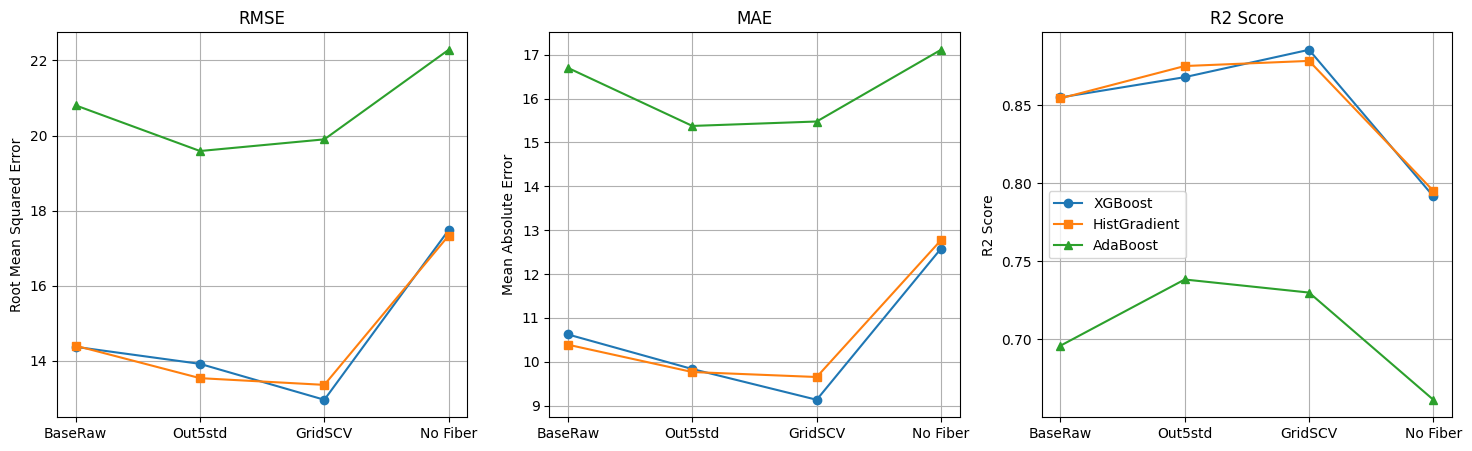

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('week7_model_comparison.csv')

xgb_data = df[df['Model'] == 'XGBRegressor']
hist_data = df[df['Model'] == 'HistGradientBoostingRegressor']
ada_data = df[df['Model'] == 'AdaBoostRegressor']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(xgb_data['Experiment'], xgb_data['RMSE'], marker='o')
ax1.plot(hist_data['Experiment'], hist_data['RMSE'], marker='s')
ax1.plot(ada_data['Experiment'], ada_data['RMSE'], marker='^')
ax1.set_title('RMSE')
ax1.set_ylabel('Root Mean Squared Error')
ax1.grid(True)

ax2.plot(xgb_data['Experiment'], xgb_data['MAE'], marker='o')
ax2.plot(hist_data['Experiment'], hist_data['MAE'], marker='s')
ax2.plot(ada_data['Experiment'], ada_data['MAE'], marker='^')
ax2.set_title('MAE')
ax2.set_ylabel('Mean Absolute Error')
ax2.grid(True)

ax3.plot(xgb_data['Experiment'], xgb_data['R2'], marker='o', label='XGBoost')
ax3.plot(hist_data['Experiment'], hist_data['R2'], marker='s', label='HistGradient')
ax3.plot(ada_data['Experiment'], ada_data['R2'], marker='^', label='AdaBoost')
ax3.set_title('R2 Score')
ax3.set_ylabel('R2 Score')
ax3.grid(True)
ax3.legend()

plt.grid(True)
plt.savefig("my_plot.png")
plt.show()
